In [3]:
#WAP in python to implement a perceptron
import numpy as np 
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

X= np.array([[1,50],[2,55],[3,60],[5,75],[6,80],[7,85]])
y= np.array([[0],[0],[0],[1],[1],[1]])

model= Perceptron(max_iter = 1000, random_state = 42)

model.fit(X,y)

y_pred= model.predict(X)
print("Actual Values: ", y)
print("Predicted Values: ", y_pred)

accuracy = accuracy_score(y, y_pred)
print("Accuracy: ", accuracy*100, "%")

print('\nWeights:', model.coef_)
print('\nBias:', model.intercept_) 

new_student=np.array([[4,70]])
prediction=model.predict(new_student)
if prediction[0]==1:
    print("New Student Prediction:Pass")
else:
    print("New Student Prediction:Fail")
    

Actual Values:  [[0]
 [0]
 [0]
 [1]
 [1]
 [1]]
Predicted Values:  [0 0 0 0 0 0]
Accuracy:  50.0 %

Weights: [[ 38. -15.]]

Bias: [-6.]
New Student Prediction:Fail


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Actual values: [0 0 0 1 1 1]
Predicted values: [0 0 0 1 1 1]

New student prediction: Pass


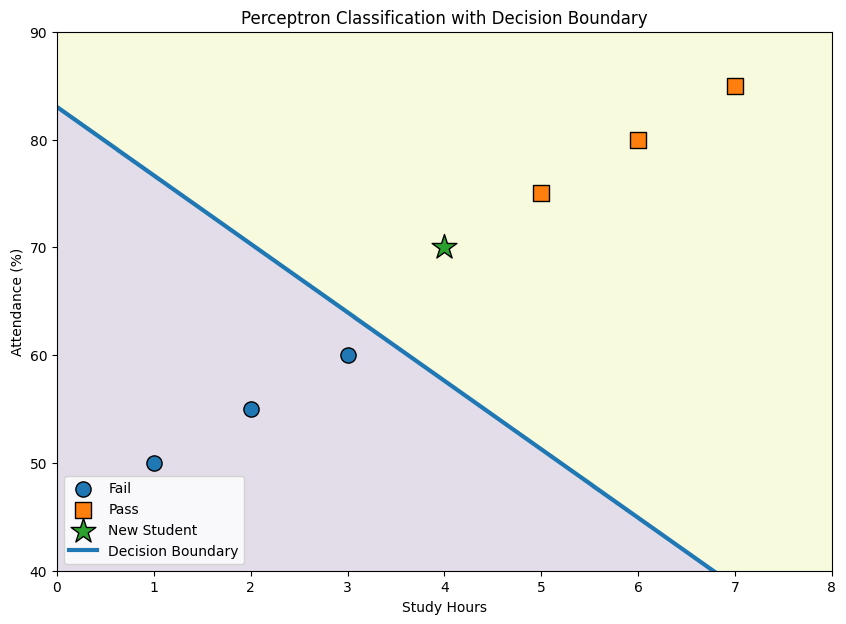

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = np.array([
    [1, 50],
    [2, 55],
    [3, 60],
    [5, 75],
    [6, 80],
    [7, 85]
])

y = np.array([0, 0, 0, 1, 1, 1])

model = make_pipeline(
    StandardScaler(),
    Perceptron(max_iter=1000, eta0=0.01, random_state=42)
)

model.fit(X, y)

predictions = model.predict(X)

print("Actual values:", y)
print("Predicted values:", predictions)

new_student = np.array([[4, 70]])
prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nNew student prediction: Pass")
else:
    print("\nNew student prediction: Fail")

x_min, x_max = 0, 8
y_min, y_max = 40, 90

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.15
)

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    marker="o",
    s=120,
    label="Fail",
    edgecolors="black"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker="s",
    s=120,
    label="Pass",
    edgecolors="black"
)

plt.scatter(
    new_student[:, 0],
    new_student[:, 1],
    marker="*",
    s=350,
    label="New Student",
    edgecolors="black"
)

scaler = model.named_steps["standardscaler"]
perceptron = model.named_steps["perceptron"]

w = perceptron.coef_[0]
b = perceptron.intercept_[0]

mean = scaler.mean_
scale = scaler.scale_

w_original = w / scale

b_original = b - np.sum(w * mean / scale)

x_values = np.linspace(0, 8, 100)

y_values = -(
    w_original[0] * x_values + b_original
) / w_original[1]

plt.plot(
    x_values,
    y_values,
    linewidth=3,
    label="Decision Boundary"
) 

plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")
plt.title("Perceptron Classification with Decision Boundary")

plt.legend()

plt.xlim(0, 8)
plt.ylim(40, 90)

plt.show()

Student	Actual	Predicted
-----------------------------------
A 	 Fail 	 Fail
B 	 Pass 	 Pass
C 	 Fail 	 Fail
D 	 Pass 	 Pass
E 	 Fail 	 Fail
F 	 Pass 	 Pass

New Student (4 hours, 70 attendance): Pass


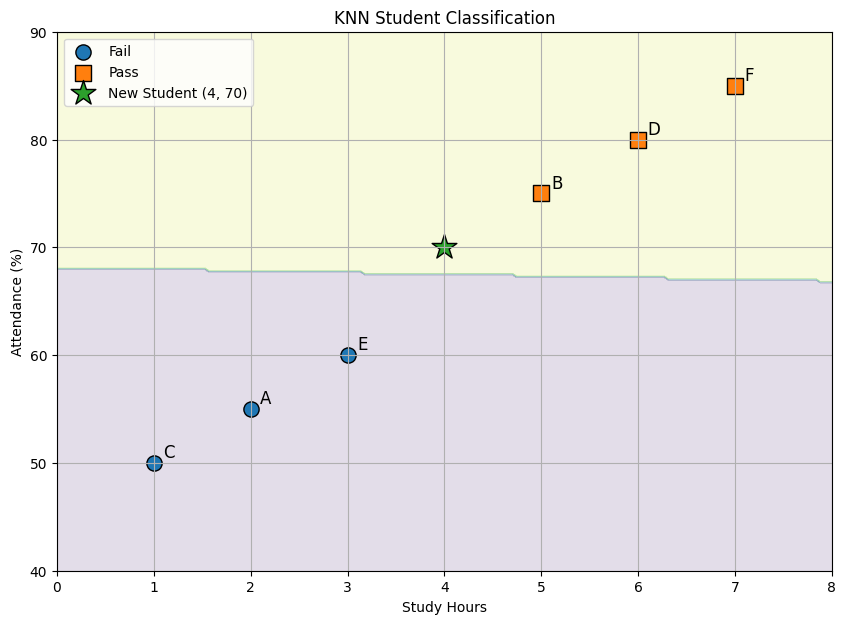

In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.neighbors import KNeighborsClassifier


X= np.array([
[2,55],
[5,75],
[1,50],
[6,80],
[3,60],
[7,85]])


y= np.array([0, 1, 0, 1, 0, 1])


k=3
knn= KNeighborsClassifier(n_neighbors=k)
knn.fit(X,y)


new_student =  np.array([[4,70]])
prediction= knn.predict(new_student)
print("K=",k) 
if prediction[0] == 1: 
    print("Pass")
else:
    print("Fail")


distances, indices = knn.kneighbors(new_student)


print("\n Nearest neighbors: ")


for i in range(k):
    index = indices[0][i]
    print(
        "Student", index +1,
        "Distance", round(distances[0][i],2),
        "Class= ",
        "PASS" if y[index] == 1 else 'FAIL'
        )
plt.figure(figsize=(10,6))
plt.scatter( 
    X[y == 0, 0],
    X[y == 0, 1],
    marker="o",
    s=120,
    label="Fail",
    edgecolors="black"
)


plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker="s",
    s=120,
    label="Pass",
    edgecolors="black"
)


plt.scatter(
    new_student[:, 0],
    new_student[:, 1],
    marker="*",
    s=350,
    label="New Student",
    edgecolors="black"
)


nearest = X[indices[0]]
plt.scatter(
    nearest[:, 0],
    nearest[:,1],
    facecolors='none',
    edgecolors= 'black',
    s=350,
    linewidths=2,
    label= 'K = 3 Neighbors'
)


for point in nearest:
    plt.plot(
        [new_student[0,0], point[0]],
        [new_student[0,1], point[1]],
        linestyle= '--',
        linewidth=1
    )


plt.xlabel('Study Hours')
plt.ylabel('Attendance (%)')
plt.title('K=3 KNN with Nearest Neighbors')
plt.legend()
plt.grid(True)
plt.show()